In [ ]:
# Import libraries
import os
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt

In [43]:
# --- BASE DIRECTORY ---
base_dir = os.getcwd()

In [ ]:
# --- LOAD METADATA ---
metadata_path = os.path.join(base_dir, "data", "HAM10000_metadata.csv")
df = pd.read_csv(metadata_path)
print("Metadata loaded:", df.shape)

Metadata loaded: (10015, 7)


In [45]:
# --- LOAD IMAGE PATHS ---
all_image_dirs = [
    os.path.join(base_dir, "data", "HAM10000_images_part_1"),
    os.path.join(base_dir, "data", "HAM10000_images_part_2")
]

image_paths = []
for dir_path in all_image_dirs:
    for fname in sorted(os.listdir(dir_path)):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(dir_path, fname))

print("Total images found:", len(image_paths))

Total images found: 10015


In [46]:
# --- LABEL DICTIONARY ---
lesion_labels = {
    'nv': 'melanocytic nevi',
    'mel': 'melanoma',
    'bkl': 'benign keratosis-like lesions',
    'bcc': 'basal cell carcinoma',
    'akiec': 'actinic keratoses',
    'vasc': 'vascular lesions',
    'df': 'dermatofibroma'
}

# --- ORDER OF LABELS ---
label_order = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

In [47]:
# --- MAP IMAGE PATHS TO IDS ---
imageid_to_path = {}
for dir_path in all_image_dirs:
    for fname in os.listdir(dir_path):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            image_id = os.path.splitext(fname)[0]  # remove .jpg
            imageid_to_path[image_id] = os.path.join(dir_path, fname)

# --- ADD NEW COLUMNS ---
df['lesion_type'] = df['dx'].map(lesion_labels)
df['label_idx'] = df['dx'].astype('category').cat.reorder_categories(label_order).cat.codes
df['path'] = df['image_id'].map(imageid_to_path)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,lesion_type,label_idx,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,benign keratosis-like lesions,2,C:\Users\yuwan\Documents\Le Wagon Project\data...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,benign keratosis-like lesions,2,C:\Users\yuwan\Documents\Le Wagon Project\data...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,benign keratosis-like lesions,2,C:\Users\yuwan\Documents\Le Wagon Project\data...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,benign keratosis-like lesions,2,C:\Users\yuwan\Documents\Le Wagon Project\data...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,benign keratosis-like lesions,2,C:\Users\yuwan\Documents\Le Wagon Project\data...


In [48]:
missing_count = df['path'].isna().sum()
if missing_count > 0:
    print(f"Warning: {missing_count} images not found in dataset folders.")
print(f"Dataset loaded successfully")
print(f"Total samples: {len(df)}")
print(f"Missing paths: {missing_count}")

Dataset loaded successfully
Total samples: 10015
Missing paths: 0


In [49]:
print("\nLesion Type Distribution:")
print(df['dx'].value_counts(Normalize)*100)


Lesion Type Distribution:
dx
nv       66.949576
mel      11.113330
bkl      10.973540
bcc       5.132302
akiec     3.265102
vasc      1.417873
df        1.148278
Name: proportion, dtype: float64


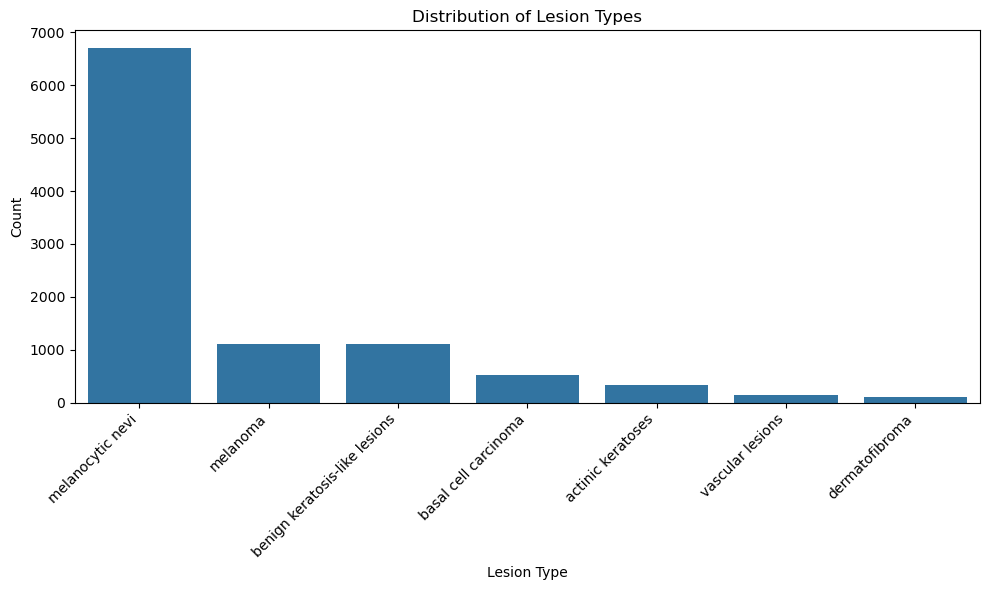

In [50]:
plt.figure(figsize=(10, 6))
order = df['lesion_type'].value_counts().index
sns.countplot(data=df, x='lesion_type', order=order)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Lesion Type')
plt.ylabel('Count')
plt.title('Distribution of Lesion Types')
plt.tight_layout()
plt.show()

## This Dataset is imbalanced dataset